# BUCSS 2026
## AI Session Hands-On Part 2: Training different models

In this notebook you will:
- Load the training data
- Train AI models
- Test on different data sets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import cmcrameri.cm as cmc
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#These are internal
from scripts.splitting_and_training import split_data, train_model, feature_selection
from scripts.plotting import obs_map


First we need to decide if we want every column in our dataframe as a feature in our ML model. 

In [35]:
city = "bern"
df = pd.read_parquet(f"../dataframes_for_training/{city}_training.parquet")

hod = df["datetime_utc"].dt.hour
doy = df["datetime_utc"].dt.dayofyear
df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

df.columns

Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_buf100', 'tcd_buf250', 'tcd_buf500', 'tcd_buf750', 'tcd_buf1000',
       'imp_nearest', 'imp_buf50', 'imp_buf100', 'imp_buf250', 'imp_buf500',
       'imp_buf750', 'imp_buf1000', 'dtm_nearest', 'lcz_nearest', 'LCZ_1',
       'LCZ_2', 'LCZ_3', 'LCZ_4', 'LCZ_5', 'LCZ_6', 'LCZ_7', 'LCZ_8', 'LCZ_9',
       'LCZ_10', 'LCZ_11', 'LCZ_12', 'LCZ_13', 'LCZ_14', 'LCZ_15', 'LCZ_16',
       'LCZ_17', 't2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10', 'sp', 'ssrd_deac',
       'tp_deac', 'rh', 'wspd', 't2m_corr', 'tod_sin', 'tod_cos', 'doy_sin',
       'doy_cos'],
      dtype='object')

### 1. Select the target variable

In [36]:
df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]

target = "temp_diff"  # "air_temperature"

target_col = df[target]  

### 2. Split the data into training and validation sets

In [37]:
# drop any possible target variable from the training dataframe (X)
X = df.drop(columns=["temp_diff", "air_temperature"]).copy()

# Set y as the target column
y = target_col

# Check split_data function to see the different types
mode = "block_spatial" # "random", "random_spatial", "block_spatial"

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = split_data(X, y, mode, spatio_temporal= True) 

training from 2019-05-14 22:00:00+00:00 to 2021-11-14 21:15:00+00:00
validation from 2021-11-14 21:15:00+00:00 to 2022-09-15 21:00:00+00:00


### 3. Feature selection

In [38]:
MODEL_TYPE = "lur" # "xgboost", "randomforest", "lur"

# Check feature_selection function
features = feature_selection(MODEL_TYPE, X_train, y_train, X_val, y_val, target)

# We subset our predictor tables by only keeping the selected features
X_train_sel = X_train[features]
X_val_sel   = X_val[features]

added ['tod_sin', 'tod_cos']         recon_val_R²=0.8509
added ['doy_sin', 'doy_cos']         recon_val_R²=0.8586
added ['d2m']                        recon_val_R²=0.8593
added ['wspd']                       recon_val_R²=0.8594
added ['bh_buf250']                  recon_val_R²=0.8690
added ['tcd_nearest']                recon_val_R²=0.8762
added ['imp_buf250']                 recon_val_R²=0.8789
added tp_deac              recon_val_R²=0.8796
added dtm_nearest          recon_val_R²=0.8803
added sp                   recon_val_R²=0.8807
added ssrd_deac            recon_val_R²=0.8809
added tp                   recon_val_R²=0.8810
added ssrd                 recon_val_R²=0.8810
LUR: 15 predictors, recon_val_R²=0.8810


### 4. Scaling



In [39]:
SCALE = True

# Save unscaled ERA5-Land input bc it's needed for error metrics
t2m_corr = X_val["t2m_corr"]

if SCALE:
    # scale all predicors except for the temporal predictors (already -1 to 1)
    cyclical = {"tod_sin", "tod_cos", "doy_sin", "doy_cos"}
    minmax_cols = [c for c in ["ssrd_deac", "tp_deac"] if c in X_train_sel.columns]

    # select the predictors to be scaled
    std_cols = [c for c in X_train_sel.columns
                if c not in cyclical and c not in minmax_cols]

    
    X_train_sel = X_train_sel.copy()
    X_val_sel = X_val_sel.copy()

    # use sklearn's StandardScaler: scales by sample mean and variance
    std_scaler  = StandardScaler()
    mm_scaler = MinMaxScaler()

    # fit the mean and variance from the training data, scale the training data
    X_train_sel[std_cols] = std_scaler.fit_transform(X_train_sel[std_cols])
    X_train_sel[minmax_cols] = mm_scaler.fit_transform(X_train_sel[minmax_cols])

    # apply the training fit to scale the validation data
    X_val_sel[std_cols]   = std_scaler.transform(X_val_sel[std_cols])    
    X_val_sel[minmax_cols]   = mm_scaler.transform(X_val_sel[minmax_cols])

In [40]:
# print(df[["air_temperature", "t2m", "t2m_corr", "dtm_nearest"]].describe())
# print("mean obs - t2m_corr:", (df["air_temperature"] - df["t2m_corr"]).mean())

### 5. Model training / fitting

In [41]:
# see train_model function

y_pred, model = train_model(X_train_sel, X_val_sel, y_train, y_val, model_type = MODEL_TYPE)

tp_deac       -2.031243
doy_cos       -1.457798
const          0.926423
ssrd_deac      0.549856
tod_sin       -0.504700
imp_buf250     0.359929
tod_cos       -0.275407
tp            -0.269996
wspd           0.257055
tcd_nearest   -0.181697
doy_sin        0.131754
sp             0.128499
dtm_nearest    0.088134
d2m           -0.059548
bh_buf250      0.045467
ssrd          -0.033365
dtype: float64


In [42]:
if MODEL_TYPE == "lur":
    if model.params["tod_sin"]:
        hours = np.arange(24)
        cos_comp = model.params["tod_cos"] * np.cos(2 * np.pi * hours / 24) 
        sin_comp = model.params["tod_sin"] * np.sin(2 * np.pi * hours / 24)
        tod = cos_comp + sin_comp
        for h, v in zip(hours, tod):
            print(f"hour {h:02d}: TOD contribution {v:+.3f} °C")
    if model.params["doy_sin"]:
        days = np.arange(15, 366, 30)
        cos_comp = model.params["doy_cos"] * np.cos(2 * np.pi * days / 365) 
        sin_comp = model.params["doy_sin"] * np.sin(2 * np.pi * days / 365)
        doy = cos_comp + sin_comp
        for d, v in zip(days, doy):
            print(f"month {int(d/30)+1}: DOY contribution {v:+.3f} °C")

hour 00: TOD contribution -0.275 °C
hour 01: TOD contribution -0.397 °C
hour 02: TOD contribution -0.491 °C
hour 03: TOD contribution -0.552 °C
hour 04: TOD contribution -0.575 °C
hour 05: TOD contribution -0.559 °C
hour 06: TOD contribution -0.505 °C
hour 07: TOD contribution -0.416 °C
hour 08: TOD contribution -0.299 °C
hour 09: TOD contribution -0.162 °C
hour 10: TOD contribution -0.014 °C
hour 11: TOD contribution +0.135 °C
hour 12: TOD contribution +0.275 °C
hour 13: TOD contribution +0.397 °C
hour 14: TOD contribution +0.491 °C
hour 15: TOD contribution +0.552 °C
hour 16: TOD contribution +0.575 °C
hour 17: TOD contribution +0.559 °C
hour 18: TOD contribution +0.505 °C
hour 19: TOD contribution +0.416 °C
hour 20: TOD contribution +0.299 °C
hour 21: TOD contribution +0.162 °C
hour 22: TOD contribution +0.014 °C
hour 23: TOD contribution -0.135 °C
month 1: DOY contribution -1.376 °C
month 2: DOY contribution -0.950 °C
month 3: DOY contribution -0.276 °C
month 4: DOY contribution +0

### 6. Error metrics

In [9]:
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

# we ensure the metrics are valid for both targets
add_back = t2m_corr.values if target == "temp_diff" else 0

y_obs = y_val.values + add_back
y_model = y_pred + add_back

rmse = root_mean_squared_error(y_obs, y_model)
r2 = r2_score(y_obs, y_model)
bias = np.mean(y_model - y_obs)


print(f"{MODEL_TYPE} Validation RMSE: {rmse:.2f} °C   R²: {r2:.2f}   Bias: {bias:.2f} °C")

# # baseline: ERA5-corrected alone vs observed
# rmse_era5 = np.sqrt(mean_squared_error(y_rec, t2m_corr.values))
# r2_era5   = r2_score(y_rec, t2m_corr.values)
# print(f"ERA5 RMSE: {rmse_era5:.3f} °C   R²: {r2_era5:.3f}")


lur Validation RMSE: 1.84 °C   R²: 0.94   Bias: 0.16 °C


In [10]:
def predict_on_all_stations(target, model, df, model_type,
                            features, scaler=None, scale_cols=None):
    Xf = df[features].copy()

    # apply the SAME train-fit scaling (LUR needs it; XGBoost is scale-invariant but harmless)
    if std_scaler is not None and std_cols is not None:
        stcols = [c for c in std_cols if c in Xf.columns]
        Xf[stcols] = std_scaler.transform(Xf[stcols])    

        mmcols = [c for c in minmax_cols if c in Xf.columns]
        Xf[mmcols] = mm_scaler.transform(Xf[mmcols])


    if model_type == "xgboost":
        dall = xgb.DMatrix(Xf, feature_names=features)
        pred = model.predict(dall)

    elif model_type == "lur":
        Xall = sm.add_constant(Xf, has_constant="add")
        pred = model.predict(Xall)

    return pd.Series(
        pred + df["t2m_corr"].values if target == "temp_diff" else pred,
        index=df.index)

features = list(X_train_sel.columns)      # the SELECTED features, same as model used
all_preds = predict_on_all_stations(target, model, df, MODEL_TYPE,
                                    features=features,)
                                    # scaler=scaler if SCALE else None,
                                    # scale_cols=scale_cols if SCALE else None)

In [11]:
def per_station_table(df, all_preds, y_val_index, target, split="all"):
    """Per-station RMSE (model vs ERA5) with LCZ and split flag.
       split: 'all', 'val', or 'train'."""
    val_ids = set(df.loc[y_val_index, "station_id"].unique())

    # reconstruct observed + model absolute temperature for ALL rows
    add_back = df["t2m_corr"].values if target == "temp_diff" else 0
    tbl = pd.DataFrame({
        "station_id": df["station_id"].values,
        "LCZ":        df["lcz_nearest"].values.astype(int),
        "obs":        df["air_temperature"].values,
        "model":      all_preds.loc[df.index].values,       # index-aligned
        "era5":       df["t2m_corr"].values,
        "datetime_utc":df["datetime_utc"].values,
    }, index=df.index).dropna(subset=["obs", "model", "era5"])

    tbl["split"] = np.where(tbl["station_id"].isin(val_ids), "val", "train")

    if split != "all":
        tbl = tbl[tbl["split"] == split]

    out = (tbl.groupby(["station_id", "LCZ", "split"])
              .apply(lambda g: pd.Series({
                  "model_rmse": root_mean_squared_error(g["obs"], g["model"]),
                  "era5_rmse":  root_mean_squared_error(g["obs"], g["era5"]),
              }), include_groups=False)
              .reset_index())
    out["improvement"] = out["era5_rmse"] - out["model_rmse"]
    return out.sort_values("improvement", ascending=False).round(3)

In [12]:
all_stations  = per_station_table(df, all_preds, y_val.index, target, split="all")
val_stations   = per_station_table(df, all_preds, y_val.index, target, split="val")
train_stations = per_station_table(df, all_preds, y_val.index, target, split="train")

print(val_stations)

      station_id  LCZ split  model_rmse  era5_rmse  improvement
6  DEU_FR_FROWIE    5   val       1.573      2.227        0.654
7  DEU_FR_FRPDAS    2   val       1.676      2.226        0.550
4  DEU_FR_FRHOLZ    5   val       1.667      2.174        0.508
8  DEU_FR_FRWSEE    6   val       1.668      2.123        0.455
5  DEU_FR_FRLORE    6   val       1.742      2.007        0.265
0  DEU_FR_FRASHA    6   val       1.792      2.008        0.216
2  DEU_FR_FREICH   11   val       2.640      2.794        0.154
3  DEU_FR_FRGUNT    9   val       1.739      1.892        0.153
1  DEU_FR_FREBNE   14   val       2.059      2.166        0.107


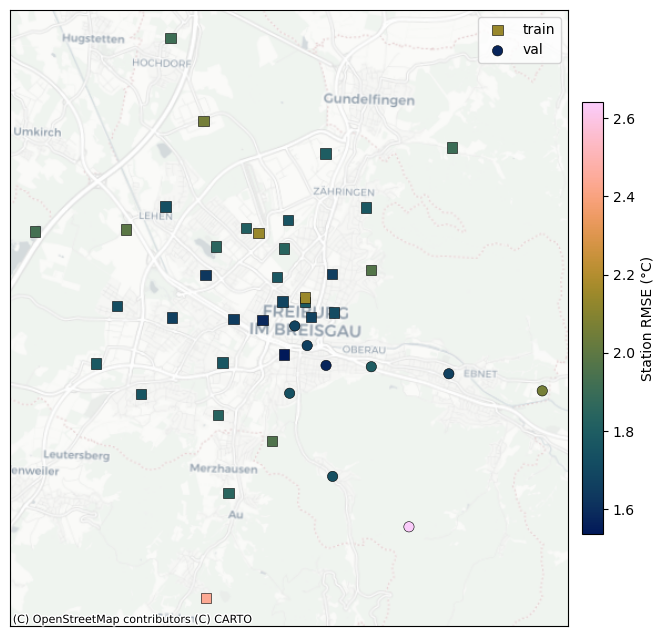

(<Figure size 900x800 with 2 Axes>, <Axes: >)

In [13]:
# 2. map: reuse all_stations, add coords, rename to what obs_map expects
coords = df.groupby("station_id")[["latitude", "longitude"]].first().reset_index()
stn = all_stations.merge(coords, on="station_id")
stn = stn.rename(columns={"model_rmse": "rmse"})

obs_map(stn, "rmse")

In [14]:
if MODEL_TYPE == "xgboost":
    explainer = shap.TreeExplainer(model)
    print("  Calculating SHAP values...")
    shap_values = explainer.shap_values(X_val_sel)

    print(f"  SHAP values: {shap_values.shape[0]} predictions × {shap_values.shape[1]} features")
    print(f"  Base value: {explainer.expected_value:.4f}")



In [15]:
if MODEL_TYPE == "xgboost":
    shap.summary_plot(
        shap_values, X_val_sel,
        feature_names=X_val_sel.columns.tolist(),
        max_display=10,
        cmap=cmc.vik,
        show=False
    )
    plt.title(f'Feature impacts across all val samples')
    plt.tight_layout()
    # plt.savefig(f'../Plots/shap/{SPLIT_TYPE_RUN}/beeswarm_{target_city}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [16]:
if MODEL_TYPE == "xgboost":
    
    # for 98th percentile value
    diff = y_model - t2m_corr.values
    perc = np.percentile(diff, 98)                      # the 98th-percentile VALUE
    sample_idx = np.abs(diff - perc).argmin() 

    # # for maximum
    # sample_idx = diff.argmax()


    val_row_label = X_val_sel.index[sample_idx]      
    station  = df.loc[val_row_label, "station_id"]
    datetime = df.loc[val_row_label, "datetime_utc"] 
    print(f"Station coordinates are {df.loc[val_row_label, "latitude"]}, {df.loc[val_row_label, "longitude"]}")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=X_val_sel.iloc[sample_idx],
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

In [17]:
if MODEL_TYPE == "xgboost":
    # the scaled val row you're explaining
    scaled_row = X_val_sel.iloc[[sample_idx]]      # keep as 1-row DataFrame

    # inverse-transform only the scaled columns
    unscaled = scaled_row.copy()
    unscaled[std_cols] = std_scaler.inverse_transform(scaled_row[std_cols])
    unscaled[minmax_cols] = mm_scaler.inverse_transform(scaled_row[minmax_cols])

    # now unscaled has real feature values (cyclical cols were never scaled, so unchanged)
    data_display = unscaled.iloc[0]                # Series of real values for this row

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=data_display.values,                    # unscaled values for display
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10, show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

In [18]:
import cmcrameri.cm as cmc

def importance(model):
    # For models trained with xgb.train() and DMatrix with feature_names
    feature_names = model.feature_names
    cmap = cmc.batlow
    # sample two colors away from extremes for clarity
    predicted_color = cmap(0.7)
        # Get importance scores (you can choose different types)
    importance_dict = model.get_score(importance_type='total_gain')  # or 'gain', 'cover'
    
    # Convert to arrays, ensuring order matches feature_names
    importances = np.array([importance_dict.get(fname, 0.0) for fname in feature_names])

    sorted_indices = np.argsort(importances)
    sorted_importances = importances[sorted_indices]
    sorted_features = [feature_names[i] for i in sorted_indices]

    # Create the horizontal bar plot
    plt.figure(figsize=(12, max(8, len(sorted_features) * 0.3)))
    bars = plt.barh(range(len(sorted_features)), sorted_importances, 
                    color=predicted_color,
                    #  alpha=0.7
                    )

    # Customize the plot
    plt.yticks(range(len(sorted_features)), sorted_features)
    plt.xlabel('Total gain')
    plt.ylabel('Features')
    # plt.title('XGBoost Feature Importances')
    plt.grid(axis='x', alpha=0.3)

        # # Add value labels on bars
        # for i, (bar, v) in enumerate(zip(bars, sorted_importances)):
        #     plt.text(v + max(sorted_importances) * 0.01, i, f'{v:.3f}', 
        #             va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nFeature importances (sorted):")
    for feat, val in zip(sorted_features[::-1], sorted_importances[::-1]):
        print(f"{feat}: {val:.6f}")
    
importance(model)

AttributeError: 'OLSResults' object has no attribute 'feature_names'